In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
(data_train, data_val, data_test), data_info = tfds.load('cats_vs_dogs',
                                               split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
                                               shuffle_files=True,
                                               as_supervised=True,
                                               with_info=True
                                               )

In [ ]:
print("Traing set size: ", len(data_train))
print("Validation set size: ", len(data_val))
print("Test set size: ", len(data_test))

In [ ]:
def normalize_img(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
# Training pipeline
data_train = data_train.map(normalize_img)
# data_train = data_train.cache()
data_train = data_train.shuffle(1000)
data_train = data_train.batch(32)
data_train = data_train.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Validation pipeline
data_val = data_val.map(normalize_img)
data_val = data_val.batch(32)
# data_val = data_val.cache()
data_val = data_val.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Testing pipeline
data_test = data_test.map(normalize_img)
data_test = data_test.batch(32)
# data_test = data_test.cache()

In [ ]:
# Flat sequential model

model = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Flatten(),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss = keras.losses.binary_crossentropy,
              metrics = [keras.metrics.BinaryAccuracy()])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       491,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,474,625 (5.63 MB)

 Trainable params: 491,541 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 983,084 (3.75 MB)

In [ ]:
model.fit(data_train, epochs=10, validation_data=data_val)

In [ ]:
print(model.history.history.keys())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(model.history.history["loss"], label = "Training loss")
axes[0].plot(model.history.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(model.history.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(model.history.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [23]:
model2 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(filters = 32, kernel_size=(3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(10, activation = 'relu'),
    layers.Dense(1, activation='sigmoid')
])

In [24]:
model2.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [25]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │     1,310,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,311,637 (5.00 MB)

 Trainable params: 1,311,637 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_model2 = model2.fit(data_train, epochs = 10, validation_data=data_val)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - binary_accuracy: 0.6210 - loss: 0.6631 - val_binary_accuracy: 0.6175 - val_loss: 0.6313
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.6881 - loss: 0.5816 - val_binary_accuracy: 0.6212 - val_loss: 0.6681
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - binary_accuracy: 0.7352 - loss: 0.5170 - val_binary_accuracy: 0.6885 - val_loss: 0.5966
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.7779 - loss: 0.4562 - val_binary_accuracy: 0.6728 - val_loss: 0.6435
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - binary_accuracy: 0.8198 - loss: 0.3845 - val_binary_accuracy: 0.6696 - val_loss: 0.7450
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - binary_accuracy: 0.8545 - loss: 0.3243 - val_binary_accuracy: 0.6759 - val_loss: 0.7961
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.8913 - loss: 0.2531 - val_binary_accuracy: 0.6736 - val_loss:

In [30]:
print(history_model2.history.keys())

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])


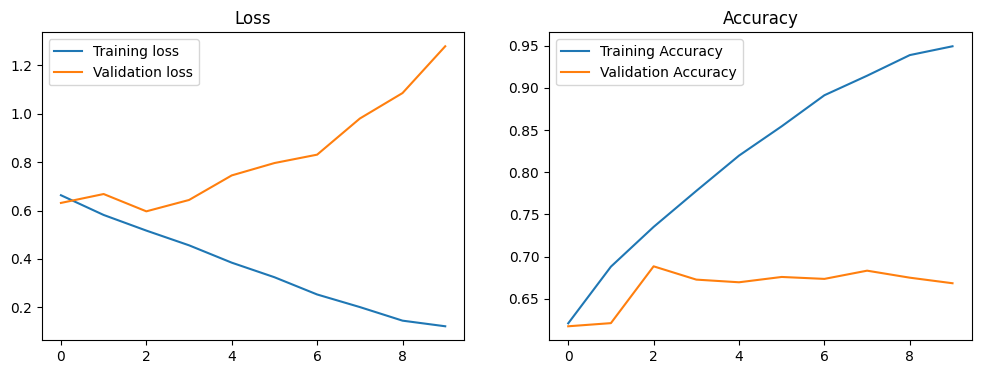

In [31]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history_model2.history["loss"], label = "Training loss")
axes[0].plot(history_model2.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_model2.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(history_model2.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [33]:
model3 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(filters = 32, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Conv2D(filters = 64, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

In [34]:
model3.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [35]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,449 (32.11 MB)

 Trainable params: 8,416,449 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_model3 = model3.fit(data_train, epochs = 20, validation_data=data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - binary_accuracy: 0.6399 - loss: 0.6672 - val_binary_accuracy: 0.6991 - val_loss: 0.5746
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - binary_accuracy: 0.7285 - loss: 0.5400 - val_binary_accuracy: 0.7264 - val_loss: 0.5393
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - binary_accuracy: 0.7798 - loss: 0.4607 - val_binary_accuracy: 0.7424 - val_loss: 0.5330
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.8408 - loss: 0.3598 - val_binary_accuracy: 0.7338 - val_loss: 0.6149
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - binary_accuracy: 0.8959 - loss: 0.2418 - val_binary_accuracy: 0.7315 - val_loss: 0.7850
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.9360 - loss: 0.1603 - val_binary_accuracy: 0.7315 - val_loss: 1.0178
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - binary_accuracy: 0.9665 - loss: 0.0883 - val_binary_accuracy: 0.7390 - val_loss:

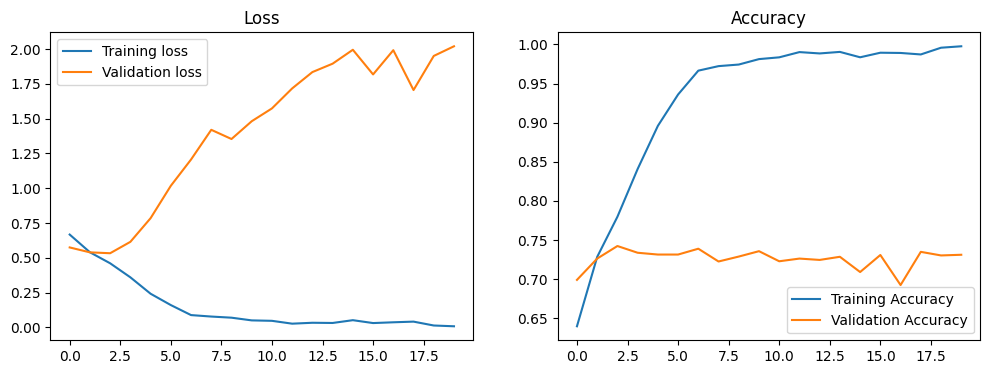

In [37]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history_model3.history["loss"], label = "Training loss")
axes[0].plot(history_model3.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_model3.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(history_model3.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [43]:
model4 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(filters = 32, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Conv2D(filters = 64, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation = 'sigmoid')
])

In [44]:
model4.compile(optimizer=keras.optimizers.Adam(0.001), loss = keras.losses.binary_crossentropy, metrics = [keras.metrics.BinaryAccuracy()])

In [45]:
model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,033 (140.75 KB)

 Trainable params: 36,033 (140.75 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history4 = model4.fit(data_train, epochs = 20, validation_data = data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - binary_accuracy: 0.5226 - loss: 0.6911 - val_binary_accuracy: 0.5381 - val_loss: 0.6859
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - binary_accuracy: 0.5740 - loss: 0.6746 - val_binary_accuracy: 0.5914 - val_loss: 0.6644
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - binary_accuracy: 0.5831 - loss: 0.6670 - val_binary_accuracy: 0.5937 - val_loss: 0.6529
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.5925 - loss: 0.6617 - val_binary_accuracy: 0.6054 - val_loss: 0.6472
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.5944 - loss: 0.6583 - val_binary_accuracy: 0.6034 - val_loss: 0.6527
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.5998 - loss: 0.6531 - val_binary_accuracy: 0.6006 - val_loss: 0.6481
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.6106 - loss: 0.6501 - val_binary_accuracy: 0.6183 - val_loss:

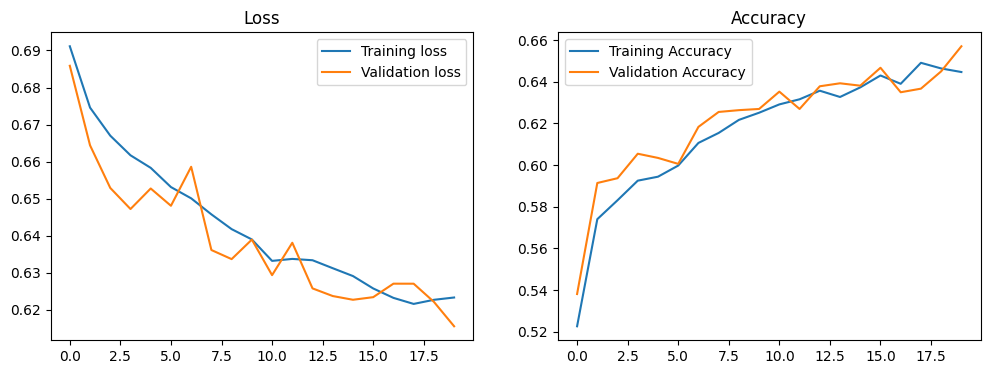

In [48]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history4.history["loss"], label = "Training loss")
axes[0].plot(history4.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history4.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(history4.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [69]:
model5 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(32, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(2),
    layers.Conv2D(64, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(2),
    layers.Conv2D(128, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation = 'sigmoid')
])

In [70]:
model5.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model5.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [72]:
history5 = model5.fit(data_train, epochs = 20, validation_data = data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - binary_accuracy: 0.5721 - loss: 0.6748 - val_binary_accuracy: 0.6034 - val_loss: 0.6594
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.5925 - loss: 0.6659 - val_binary_accuracy: 0.5779 - val_loss: 0.6634
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - binary_accuracy: 0.6092 - loss: 0.6556 - val_binary_accuracy: 0.6289 - val_loss: 0.6411
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - binary_accuracy: 0.6184 - loss: 0.6482 - val_binary_accuracy: 0.6324 - val_loss: 0.6351
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.6314 - loss: 0.6376 - val_binary_accuracy: 0.6393 - val_loss: 0.6287
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.6430 - loss: 0.6331 - val_binary_accuracy: 0.6390 - val_loss: 0.6249
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.6605 - loss: 0.6176 - val_binary_accuracy: 0.6401 - val_loss:

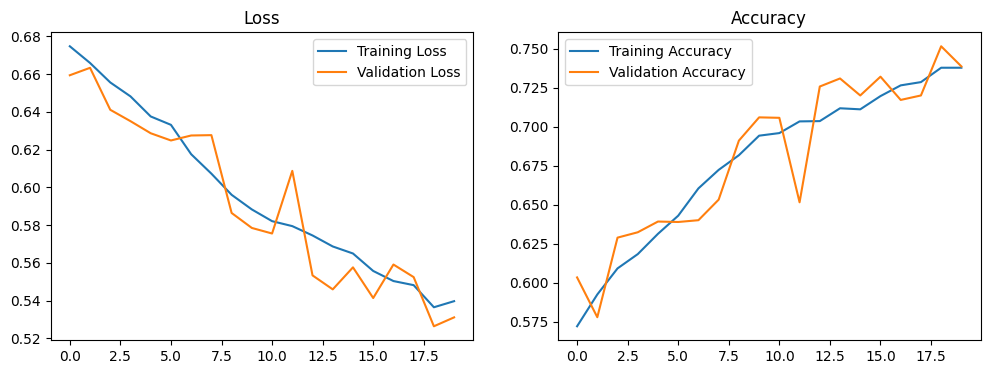

In [73]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history5.history["loss"], label = "Training Loss")
axes[0].plot(history5.history["val_loss"], label = "Validation Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history5.history["binary_accuracy"], label = "Training Accuracy")
axes[1].plot(history5.history["val_binary_accuracy"], label = "Validation Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

In [78]:
model6 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    # layers.Conv2D(32, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    # layers.MaxPool2D(2),
    layers.Conv2D(64, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(2),
    layers.Conv2D(128, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(256, (3, 3), padding = 'same'),
    layers.MaxPool2D(),
    # layers.Conv2D(512, (3, 3), padding = 'same'),
    # layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.8),
    layers.Dense(1, activation = 'sigmoid')
  ])

In [79]:
model6.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,841 (1.54 MB)

 Trainable params: 403,841 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
model6.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [81]:
history6 = model6.fit(data_train, epochs = 20, validation_data = data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 53s 88ms/step - binary_accuracy: 0.5447 - loss: 0.6905 - val_binary_accuracy: 0.5009 - val_loss: 0.6926
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - binary_accuracy: 0.5287 - loss: 0.6892 - val_binary_accuracy: 0.6040 - val_loss: 0.6699
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - binary_accuracy: 0.5311 - loss: 0.6889 - val_binary_accuracy: 0.4994 - val_loss: 0.6932
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - binary_accuracy: 0.5034 - loss: 0.6933 - val_binary_accuracy: 0.4994 - val_loss: 0.6930
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - binary_accuracy: 0.5033 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss: 0.6931
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - binary_accuracy: 0.5012 - loss: 0.6932 - val_binary_accuracy: 0.4994 - val_loss:

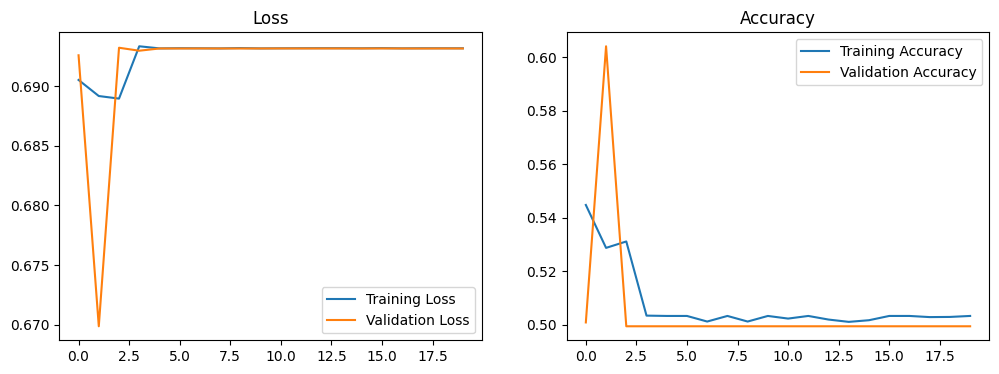

In [82]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history6.history["loss"], label = "Training Loss")
axes[0].plot(history6.history["val_loss"], label = "Validation Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history6.history["binary_accuracy"], label = "Training Accuracy")
axes[1].plot(history6.history["val_binary_accuracy"], label = "Validation Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

In [88]:
model7 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    # layers.Conv2D(32, (3, 3), padding = 'same'),
    # layers.BatchNormalization(),
    # layers.MaxPool2D(2),
    layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(2),
    layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
    # layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'),
    layers.MaxPool2D(),
    layers.Conv2D(512, (3, 3), padding = 'same', activation = 'relu'),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.25),
    layers.Dense(1, activation = 'sigmoid')
  ])

In [89]:
model7.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,616,769 (6.17 MB)

 Trainable params: 1,616,769 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model7.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [91]:
history7 = model7.fit(data_train, epochs = 20, validation_data = data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 44s 73ms/step - binary_accuracy: 0.5721 - loss: 0.6703 - val_binary_accuracy: 0.6407 - val_loss: 0.6313
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - binary_accuracy: 0.6614 - loss: 0.6202 - val_binary_accuracy: 0.6805 - val_loss: 0.6050
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - binary_accuracy: 0.7023 - loss: 0.5739 - val_binary_accuracy: 0.7189 - val_loss: 0.5604
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - binary_accuracy: 0.7332 - loss: 0.5405 - val_binary_accuracy: 0.7415 - val_loss: 0.5198
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - binary_accuracy: 0.7636 - loss: 0.4943 - val_binary_accuracy: 0.7484 - val_loss: 0.5005
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - binary_accuracy: 0.7963 - loss: 0.4439 - val_binary_accuracy: 0.8037 - val_loss: 0.4481
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - binary_accuracy: 0.8299 - loss: 0.3856 - val_binary_accuracy: 0.8238 - val_loss:

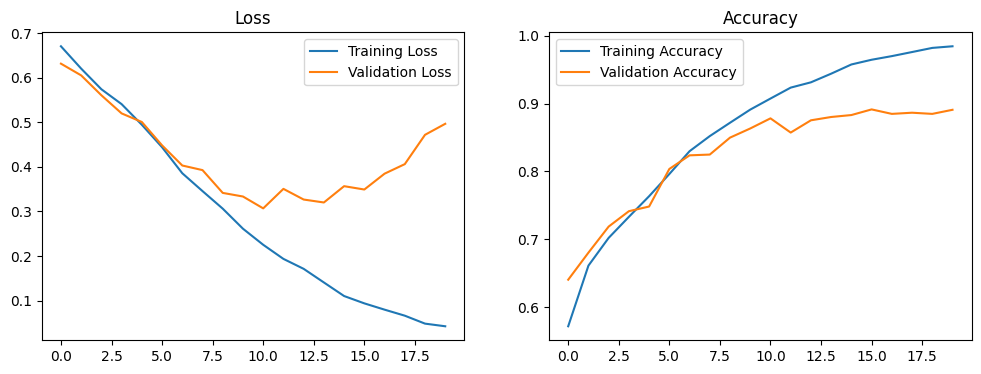

In [92]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history7.history["loss"], label = "Training Loss")
axes[0].plot(history7.history["val_loss"], label = "Validation Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history7.history["binary_accuracy"], label = "Training Accuracy")
axes[1].plot(history7.history["val_binary_accuracy"], label = "Validation Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()